# 1a

The value of the derivative is highest is ~0.024979. At its lowest, it is 4.77429598132981e-06, which occurs at the boundary points. Thinking of the sigmoid as an approximation to an edge in 1d, the derivative gives us information about the location and sharpness of an edge. The edge location is denoted by the highest value of the derivative, which would mark the point of starkest contrast aka the most abrupt brightness change. The magnitude of this point indicates exactly how stark this contrast is.

Maximum value 0.024979187478940124
Associated input to achieve max: 0.5
Minimum value 4.77429598132981e-06 at boundaries


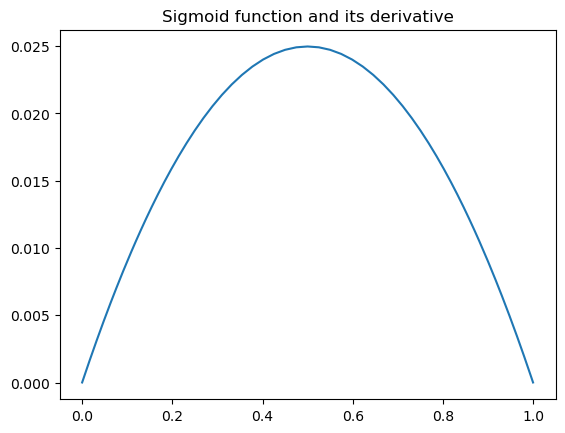

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

def sigmoid(x):
    return 1/(1+math.e**(-2*x))

n = 201
x = sigmoid(np.linspace(-5, 5, n))
dx = np.gradient(x)
plt.plot(x, dx)
plt.title("Sigmoid function and its derivative")
print(f"Maximum value {np.max(dx)}")
print(f"Associated input to achieve max: {x[np.argmax(dx)]}")
print(f"Minimum value {np.min(dx)} at boundaries")


# 1b

0.024979187478940124


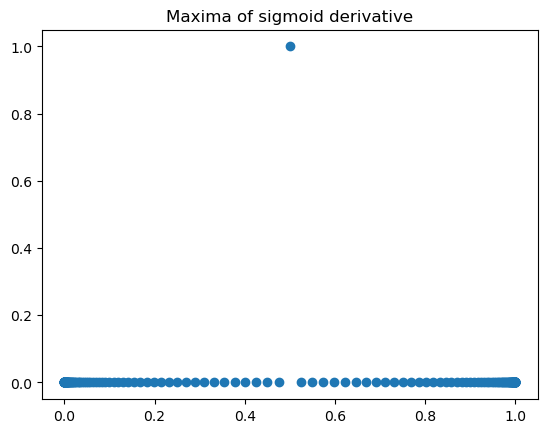

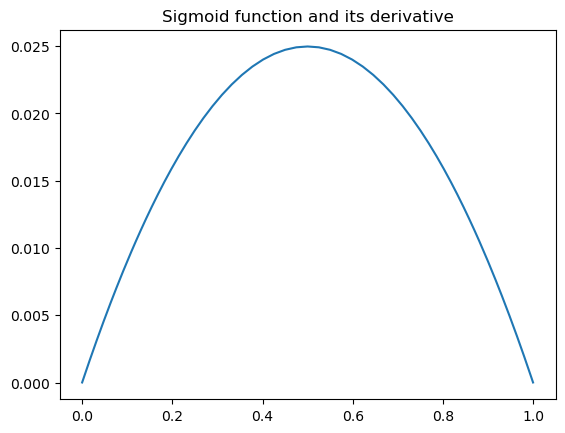

In [5]:
output=[]
for idx, d in enumerate(dx):
    if idx == 0 or idx == n-1:
        output.append(0) # padding effectively for boundaries
    elif d > dx[idx-1] and d > dx[idx+1]:
        output.append(1)
        print(d)
    else:
        output.append(0)
plt.scatter(x, output)
plt.title("Maxima of sigmoid derivative")
plt.show()

plt.plot(x, dx)
plt.title("Sigmoid function and its derivative")
plt.show()

# 1c

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


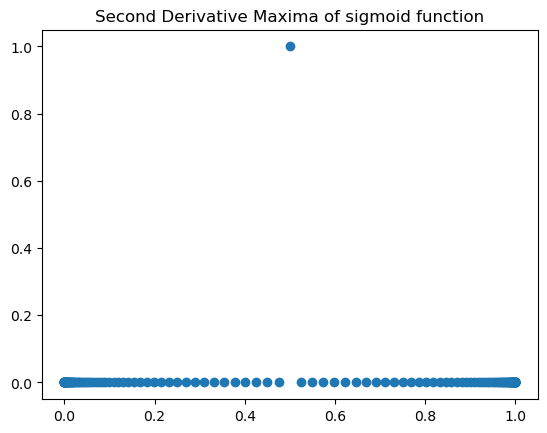

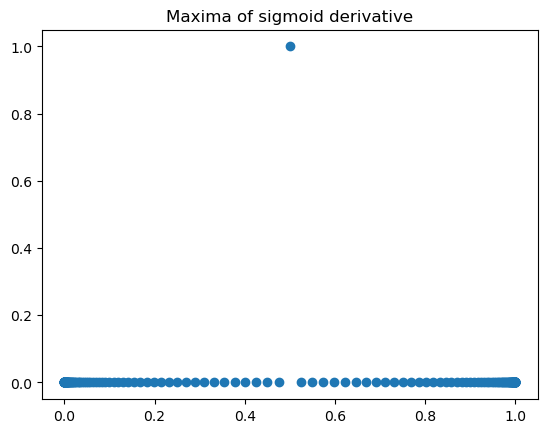

In [6]:
x = sigmoid(np.linspace(-5, 5, n))
dx = np.gradient(sigmoid(np.linspace(-5, 5, n)))
xs = np.arange(1, n-1)
xpeaks = (dx[xs-1] <= dx[xs]) & (dx[xs] > dx[xs+1])
xpeaks_01 = xpeaks.astype(int)
print(xpeaks_01)
plt.scatter(x[xs], xpeaks_01)
plt.title("Second Derivative Maxima of sigmoid function")
plt.show()
plt.scatter(x, output)
plt.title("Maxima of sigmoid derivative")
plt.show()


# 1d

This zero crossing point (from pos to neg) of the second deriv matches the maxima of the first derivative from part 1a. Therefore, the zero crossing of the second derivative indicate maxima/minima of the first derivative.

Inflection point at: [0.5]
Value at inflection point: [0.73105858]
Derivative at inflection point: [0.02497919]


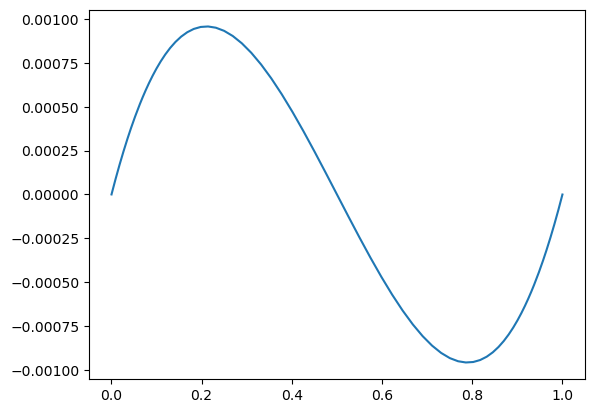

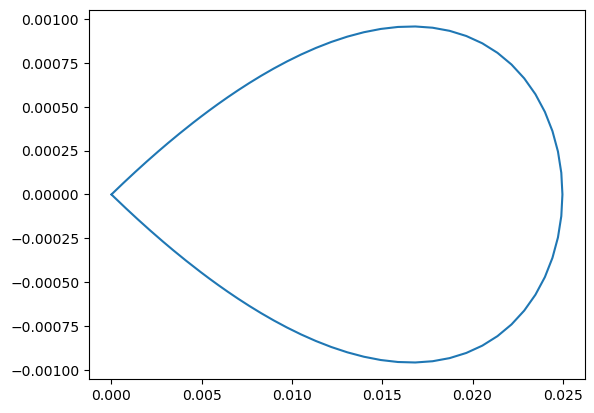

In [7]:
x = sigmoid(np.linspace(-5, 5, n))
dx = np.gradient(sigmoid(np.linspace(-5, 5, n)))
ddx = np.gradient(dx)
crossing_point = np.where(np.diff(np.sign(ddx)))[0]
print("Inflection point at:", x[crossing_point])
print("Value at inflection point:", sigmoid(x[crossing_point]))
print("Derivative at inflection point:", dx[crossing_point])
plt.plot(x, ddx)
plt.show()
plt.plot(dx, ddx)
plt.show()

# 1e

The second derivative represents change in the rate of change (concavity). Before the midopint the function will be concave up, afterwards it will be concave down. Therefore, the point where the 2nd derivative crosses zero (inflection point) will occour at the location of maximum slope. At this point, the sign will flip from positive to negative, and therefore if we use that knowledge to spot that exact location, we can localize the edge. The plot shows this pretty nicely, as we can clearly see the localization of the inflection point and how that lines up perfectly with the results from previous parts of this pset.

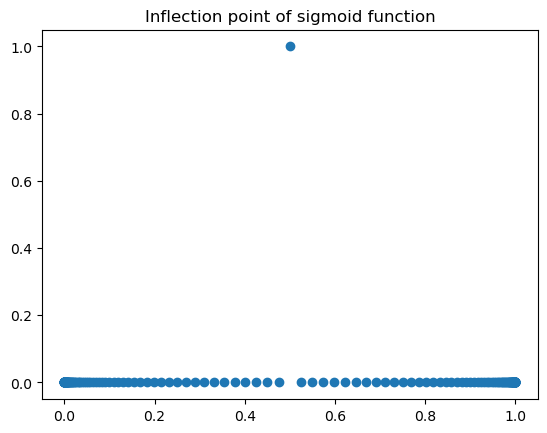

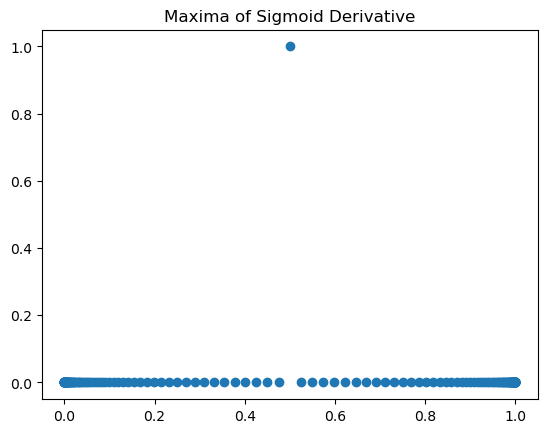

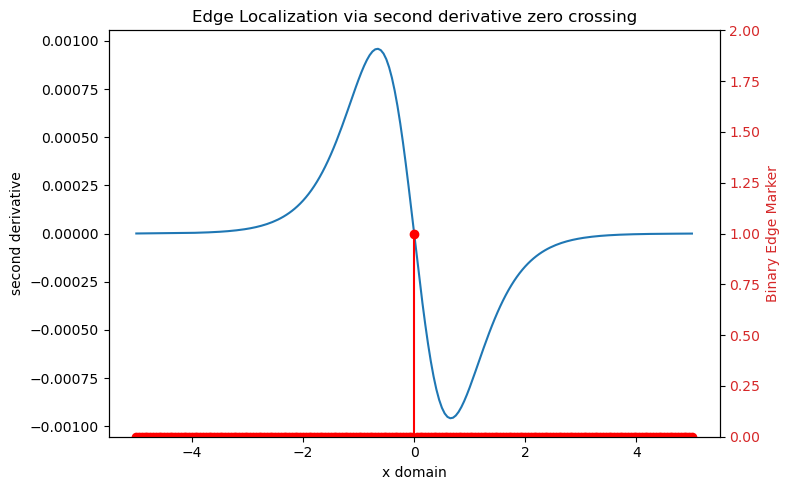

In [8]:
vec = []
domain_x = np.linspace(-5, 5, n)
x = sigmoid(domain_x)
dx = np.gradient(x)
ddx = np.gradient(dx)
vec = np.zeros_like(ddx)
for idx in range(n-1):
    if ddx[idx] > 0 and ddx[idx+1] <=0:
        vec[idx] = 1
vec = np.array(vec)

plt.scatter(x, vec)
plt.title("Inflection point of sigmoid function")
plt.show()
plt.scatter(x, output)
plt.title("Maxima of Sigmoid Derivative")
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel("x domain")
ax1.set_ylabel("second derivative")
ax1.plot(domain_x, ddx, label="Second derivative")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()  
ax2.set_ylabel("Binary Edge Marker", color="tab:red")
ax2.stem(domain_x, vec, linefmt='r-', markerfmt='ro', basefmt=' ', label="Edge Location")
ax2.tick_params(axis='y', labelcolor="tab:red")
ax2.set_ylim(0, 2)

plt.title("Edge Localization via second derivative zero crossing")
fig.tight_layout()
plt.show()

# 2a

The sobel x filter detects vertical edges. Simply observe the front of the face (nasal region) to see this edge detection clearly. Notice how it has the strongest edges on flat vertical regions of high contrast like the edge of the face. In contrast, the strobel y filter higlights horizontal edges, which is especially noticable if we look at the shoulders. These filters relate directly to part 1 because the sobel filter gives the partial derivatives in the x and y direction respectively! With each partial giving us either horizonal or vertical edge detection! It is the exact same principle, with derivatives detecting rapid changes in intensity (edges). In 1D we just needed one derivative, but now that we are in 2D we need two partials to capture the edges.

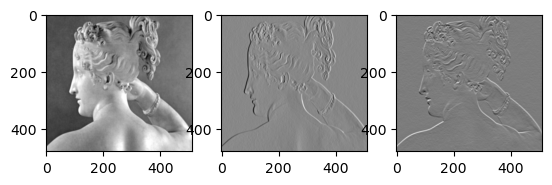

In [9]:
from scipy.ndimage import convolve
from PIL import Image

sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])
sobel_y = np.array([[1,2,1],
                    [0,0,0],
                    [-1,-2,-1]])

sobel_x = sobel_x / np.sum(np.abs(sobel_x))
sobel_y = sobel_y / np.sum(np.abs(sobel_y))

image = "Paolina-3.tiff"
im = np.array(Image.open(image))
im = im.astype("float")/255
x_dim, y_dim = im.shape

im_sobel_x = convolve(im, sobel_x)
im_sobel_y = convolve(im, sobel_y)
fig, ax = plt.subplots(1,3)
ax[0].imshow(im, cmap="gray")
ax[1].imshow(im_sobel_x, cmap="gray")
ax[2].imshow(im_sobel_y, cmap="gray")
plt.show()

# 2b

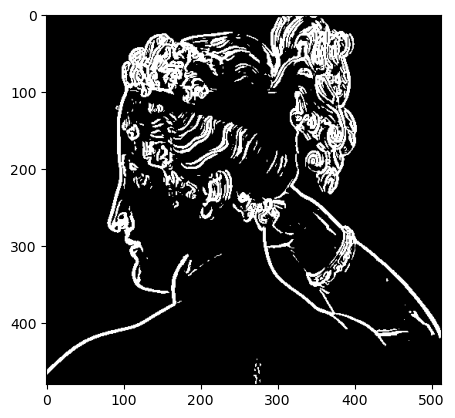

In [10]:
magnitude = np.sqrt(im_sobel_x**2 + im_sobel_y**2)
average_intensity = np.mean(magnitude)
magnitude = (magnitude > 2*average_intensity).astype(float)
plt.imshow(magnitude, cmap='gray')
plt.show()

# 2c

I see a much less noisy plot of all of the edges. These edges are much more precise and higher resolution, and it makes it much easier for me to pin down the exact location of an edge. This thnning is nice because we use the thresholding to just keep the strongest edge pixels, letting us throw out unecessary ones (the weaker neighboring pixels). In parts 1b & c we compute the numerical derivative of the sigmoid. The sidmoid represented a single 1D edge and the derivative formed a peak at the location of the edge. Now, we are using the same principles, except in two dimmensions. We are running that same 1D logic along the partial derivatives in the horizonal and vertical directions of the image. We need this step to get an edge map because the sobel filters leave us with sizeable gradient magnitudes which makes it difficult to see the exact edge location as its almost spreading out the edge emphasis over a neighborhood of pixels when we really only want it to be on a few pixels.

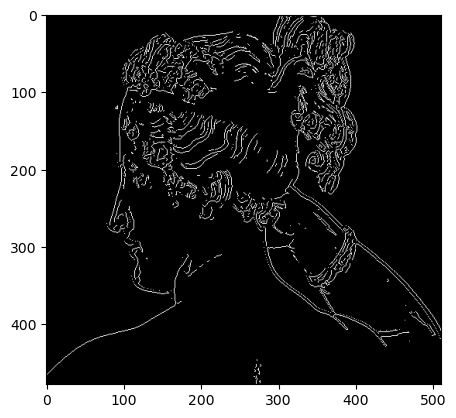

In [11]:
im = magnitude

m, n = im.shape; xs = np.arange(1,n-1); ys = np.arange(1,m-1);
xpeaks = (im[ys][:,xs-1] <= im[ys][:,xs]) & (im[ys][:,xs] > im[ys][:,xs+1])
ypeaks = (im[ys-1][:,xs] <= im[ys][:,xs]) & (im[ys][:,xs] > im[ys+1][:,xs]) 
im = im[ys][:,xs].astype(bool) & ( xpeaks | ypeaks )
plt.imshow(im, cmap="gray")
plt.show()

# 2d

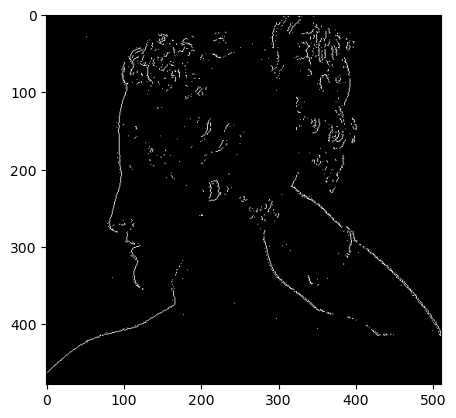

In [12]:
from scipy.ndimage import convolve
from PIL import Image
image = 'Paolina-3.tiff'
im = np.array(Image.open(image))
im = im.astype('float')/255
x_dim, y_dim = im.shape

rand = np.random.randn(x_dim, y_dim)
im = im + 0.05*(rand)
plt.imshow(im, cmap='gray')

sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])
sobel_y = np.array([[1,2,1],
                    [0,0,0],
                    [-1,-2,-1]])

sobel_x = sobel_x / np.sum(np.abs(sobel_x))
sobel_y = sobel_y / np.sum(np.abs(sobel_y))

im_sobel_x = convolve(im, sobel_x)
im_sobel_y = convolve(im, sobel_y)

magnitude = np.sqrt(im_sobel_x**2 + im_sobel_y**2)
average_intensity = np.mean(magnitude)
magnitude = (magnitude > 3*average_intensity).astype(float)

im = magnitude

m, n = im.shape; xs = np.arange(1,n-1); ys = np.arange(1,m-1);
xpeaks = (im[ys][:,xs-1] <= im[ys][:,xs]) & (im[ys][:,xs] > im[ys][:,xs+1])
ypeaks = (im[ys-1][:,xs] <= im[ys][:,xs]) & (im[ys][:,xs] > im[ys+1][:,xs]) 

im = im[ys][:,xs].astype(bool) & ( xpeaks | ypeaks )

plt.imshow(im, cmap='gray')
plt.show()

# 2e

Noise is problematic because it is inherently adding rapid changes to the image which will cause the derivative to identify said noise as an edge. This causes the edge output to become much grainier, as the noise drowns out the actual edges.
Gaussian blur improves performance greatly! Gaussian blur suppresses the high frequency noise while preserving the important larger intensity trasitions that we care about (the real edges themselves). 

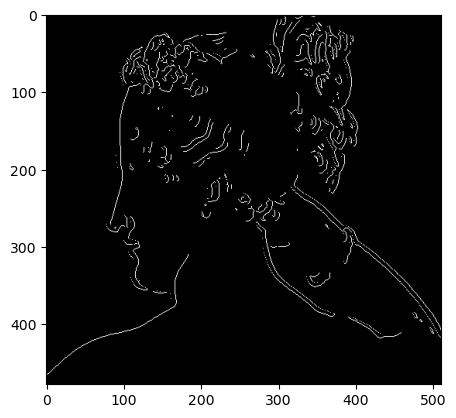

In [13]:
from scipy.ndimage import convolve
from PIL import Image

# blur from previous pset submission
def blurfilter(sigma, n=None):
	"""BLURFILTER Creates a Gaussian blur filter.
	FILT = BLURFILTER(SIGMA, N) creates a Gaussian blur filter with
	bandwidth parameter SIGMA, and size N x N. If N isn't specified, it
	defaults to ceil(6*sigma) + 1.

	The output of this function is the filter FILT."""

	if n == None:
		n = int(np.ceil(6*sigma)) + 1
			
	rad = (n - 1)/2
	xs, ys = np.meshgrid(np.linspace(-rad, rad, n), np.linspace(rad, -rad, n))
		
	# Your code here -- (make sure you understand what xs and ys represent!)
	# xs = [-rad, ..., rad] repeated n times as rows
	# ys = [rad, ..., -rad] repeated n times as cols
	# rad = radius of filter (in pixels)
	filter = np.exp(-(xs**2 + ys**2) / (2 * sigma**2))

	filter = filter / np.sum(filter) 
	return filter


image = 'Paolina-3.tiff'
im = np.array(Image.open(image))
im = im.astype('float')/255
x_dim, y_dim = im.shape

rand = np.random.randn(x_dim, y_dim)
im = im + 0.05*(rand)

im = convolve(im, blurfilter(2.0))

sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])
sobel_y = np.array([[1,2,1],
                    [0,0,0],
                    [-1,-2,-1]])

sobel_x = sobel_x / np.sum(np.abs(sobel_x))
sobel_y = sobel_y / np.sum(np.abs(sobel_y))

im_sobel_x = convolve(im, sobel_x)
im_sobel_y = convolve(im, sobel_y)

magnitude = np.sqrt(im_sobel_x**2 + im_sobel_y**2)
average_intensity = np.mean(magnitude)
magnitude = (magnitude > 3*average_intensity).astype(float)

im = magnitude

m, n = im.shape; xs = np.arange(1,n-1); ys = np.arange(1,m-1);
xpeaks = (im[ys][:,xs-1] <= im[ys][:,xs]) & (im[ys][:,xs] > im[ys][:,xs+1])
ypeaks = (im[ys-1][:,xs] <= im[ys][:,xs]) & (im[ys][:,xs] > im[ys+1][:,xs]) 

im = im[ys][:,xs].astype(bool) & ( xpeaks | ypeaks )

plt.imshow(im, cmap='gray')
plt.show()

# 2f

I expect that the laplacian would we used to search for zero crossings, which would effectively serve as an edge detector. It would be the sum of partial second order derivatives in the vertical and horizontal direction, so the process is literally the exact same as before, except now we are looking for zero crossings!

The role of the gaussian is also critical. It is used once again to suppress noise. Note that this is just our favorite mexian hat filter we always talk about, and now it makes sense why we care so much about it. The process would be in two steps: gaussian smoothing first to remove noise just like in 2e, then apply the laplacian to determine the edge locations. 

In [14]:
import numpy as np

def gaborfilter(theta, wavelength, phase, sigma, aspect, ksize=None):

	"""
	GB = GABORFILTER(THETA, WAVELENGTH, PHASE, SIGMA, ASPECT, KSIZE)
	creates a Gabor filter GB with orientation THETA (in radians),
	wavelength WAVELENGTH (in pixels), phase offset PHASE (in radians),
	envelope standard deviation SIGMA, aspect ratio ASPECT, and dimensions
	KSIZE x KSIZE. KSIZE is an optional parameter, and if omitted default
	dimensions are selected.
	 """

	if ksize is None:
		ksize = 8*sigma*aspect

	if type(ksize) == int or len(ksize) == 1:
		ksize = [ksize, ksize]

	xmax = np.floor(ksize[1]/2.)
	xmin = -xmax
	ymax = np.floor(ksize[0]/2.)
	ymin = -ymax

	xs, ys = np.meshgrid(np.arange(xmin,xmax+1), np.arange(ymax,ymin-1,-1))

	# Your code here

	# note: my gabor filter generates all 16 at once, and returns them
	# as a list. Got permission from a ULA that this approach was okay.
	orientations_edge = np.linspace(0, 7*np.pi/4.0, num=8, endpoint=True)
	orientations_line = np.linspace(0, 3*np.pi/4.0, num=4, endpoint=True)
	filters = []

	for theta in orientations_edge:
		x_prime = xs * np.cos(theta) + ys * np.sin(theta)
		y_prime = -xs * np.sin(theta) + ys * np.cos(theta)

		g_ij = (np.sin(2 * np.pi * y_prime / wavelength) *
				np.exp(-(x_prime**2 / (2 * (sigma * aspect)**2) +
						y_prime**2 / (2 * sigma**2))))

		g_ij = g_ij - np.mean(g_ij)
		g_ij = g_ij / np.sqrt(np.sum(g_ij**2))
		filters.append(g_ij)

	for theta in orientations_line:
		x_prime = xs * np.cos(theta) + ys * np.sin(theta)
		y_prime = -xs * np.sin(theta) + ys * np.cos(theta)

		g_ij = (np.cos(2 * np.pi * y_prime / wavelength) *
				np.exp(-(x_prime**2 / (2 * (sigma * aspect)**2) +
						y_prime**2 / (2 * sigma**2))))

		g_ij = g_ij - np.mean(g_ij)
		g_ij = g_ij / np.sqrt(np.sum(g_ij**2))
		filters.append(g_ij)

	for theta in orientations_line:
		x_prime = xs * np.cos(theta) + ys * np.sin(theta)
		y_prime = -xs * np.sin(theta) + ys * np.cos(theta)

		g_ij = (-np.cos(2 * np.pi * y_prime / wavelength) *
				np.exp(-(x_prime**2 / (2 * (sigma * aspect)**2) +
						y_prime**2 / (2 * sigma**2))))

		g_ij = g_ij - np.mean(g_ij)
		g_ij = g_ij / np.sqrt(np.sum(g_ij**2))
		filters.append(g_ij)

	return filters

# 3a

I selected wavelength of 4 and a standard deviation of 1 (as suggested in the homework problem statement, which claimed that wavelength should be approx 4*sd). This ensures that the gaussian envelope is  4 standard deviations wide which captures one full period of the sin wave. This is a great balance because it does a solid job balancing the tradeoff between spatial localization and frequency sensitivity. Spatial localization is crucial for pinpointing precise edge coordinates nad frequency sensitivity is important for isolating textures. I chose smaller values to focus on capturing the finer details of Paolina like her curls. I also set the aspect ratio, as suggested, to 3 as this elongates the gaussian envelope into more of a line detector shape which is important for properly capturing edges while suppressing noise. 

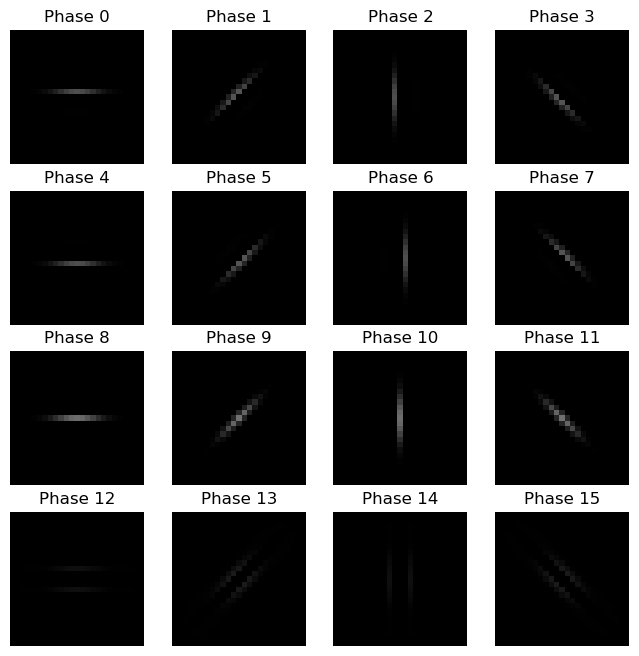

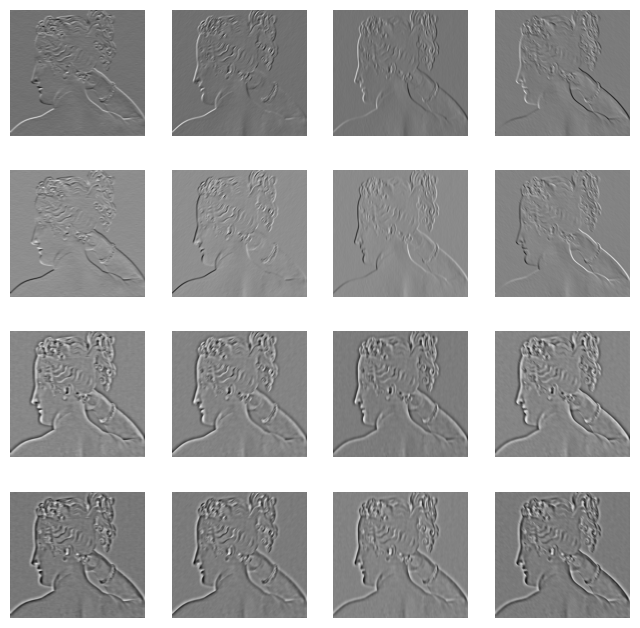

In [15]:
sigma=1
aspect=3
wavelength=4 # wavelength = 4* sigma
theta = 3*np.pi/4
phase = 0

# my gabor filter generates all 16 at once, and returns them
# as a list. Got permission from a ULA that this approach was okay.
filters = gaborfilter(theta, wavelength, phase,
                        sigma, aspect)

fig, ax = plt.subplots(4,4,figsize=(8,8))

for idx, (ax, filt) in enumerate(zip(ax.flatten(), filters)):
    ax.imshow(filt, cmap='gray', vmin=0,vmax=1)
    ax.set_title(f'Phase {idx}')
    ax.axis('off')

plt.show()

image = 'Paolina-3.tiff'
im = np.array(Image.open(image))
im = im.astype('float')/255
x_dim, y_dim = im.shape

fig, ax = plt.subplots(4,4,figsize=(8,8))

for idx, (ax, filt) in enumerate(zip(ax.flatten(), filters)):
    filtered_im = convolve(im, filt)
    ax.imshow(filtered_im, cmap='gray')
    ax.axis('off')


# 3b

For paolina, the difference between the edge, dark line, and bright line enhancer is determined by phase / symmetry of the gabor filter relative to the image features. The edge enhancer is odd symmetric and responds to strongly step like changes in intensity, highlighting boundaries like the jawline and nose. The bright line enhancer is even symmetric wtih a central positive peak, ignoring step edges and acting as a ridge detector it isolates thin bright structures like bright highlights on the nose or hair features / texture. It is great at detecting light structures on black backgrounds. Conversely, the dark line enhancer has a central negative trough and is specialized for detecting dark structures on light backgrounds, such as eye details or lips. Overall, the edge enhancer outliens regions wheras the line enhancer emphasize specific texture based details resulting from contrast polarity (light on dark, dark on light.) 

For obvious examples of this behavior that are also labelled more clearly, refer to my 3b extra credit response below.


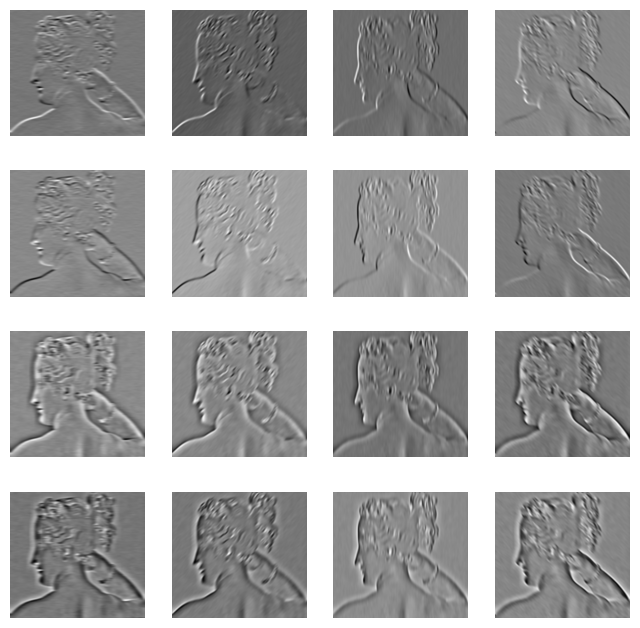

In [16]:
image = 'Paolina-3.tiff'
im = np.array(Image.open(image))
im = im.astype('float')/255
x_dim, y_dim = im.shape

filters = gaborfilter(theta=np.pi/4, wavelength=12, phase=0,
                 sigma=3, aspect=2)

fig, ax = plt.subplots(4,4,figsize=(8,8))

for idx, (ax, filt) in enumerate(zip(ax.flatten(), filters)):
    filtered_im = convolve(im, filt)
    ax.imshow(filtered_im, cmap='gray')
    ax.axis('off')

# gabor filter: gaussian modulated by a sinusoid

# 3b Extra Credit

For this problem we have two examples that will demonstrate the gabor filter in all of its glory. One of the examples is a high contrast scan of the gutenberg bible. Another is a synthetic example with two dark lines and two bright lines strewn accross a neutral backdrop.
Parameter selection was done purely through brute force experimentation. We began with the heuristics from the homework problem statement (wavelength approx 4x standard deviation) and just played with tweaking each parameter individually from there until the book filters showed reasonably visible print. Incorrect wavelength selection would result in the letters all blending together and making the filtered images look brutal. Although you cant exactly read the text from the edge enhancer / line enhancers, it still looks solid and you can clearly see the behavior of each of the filters.

For testings sake, we simply selected one filter from each of the three categories with the same orientation (0 degrees) then plotted the difference. It is quite clear that the phase of the filter dicates the feature type detected. For the book, we used horizontal filters to perform well at reading the text. For the synthethic image we used vertical filters to find edges along those lines. 

The results on both images confirm the phase selectivity of the Gabor Filters. The original synthetic image consists of dark bars on the left and light bars on the right. The edge enhancer acts purely as a gradient detector, and it hightlights the boundaries of both the dark and bright bars indistriminately. In contrast, the line enhancers successfully discriminate based on contrast polarity. The bright line enhancer correctly identifies the bright bars on the right, finding peaks in intensity. Noteably it also generates some faint less substantial enhancements around the edges of black bars because the filters negative side lobes interact with the sharp boundaries of the opposing dark features. Conversely, the dark line enhancer isolates the dark bars on the left by finding the intensity troughs, with only some minor artifacts around the bright bars. This demonstrates that while the filters are not perfectly blind to the opposing polarity due to these side lobe interactions, the significant difference in response magnitude makes them effective at distinguishing light structures from dark ones.

The bible example exhibits this same behavior, except we leverage horizonal filters so the orientation distinction is clearly evident. The dark line enhancers do a great job enhancing the black text!

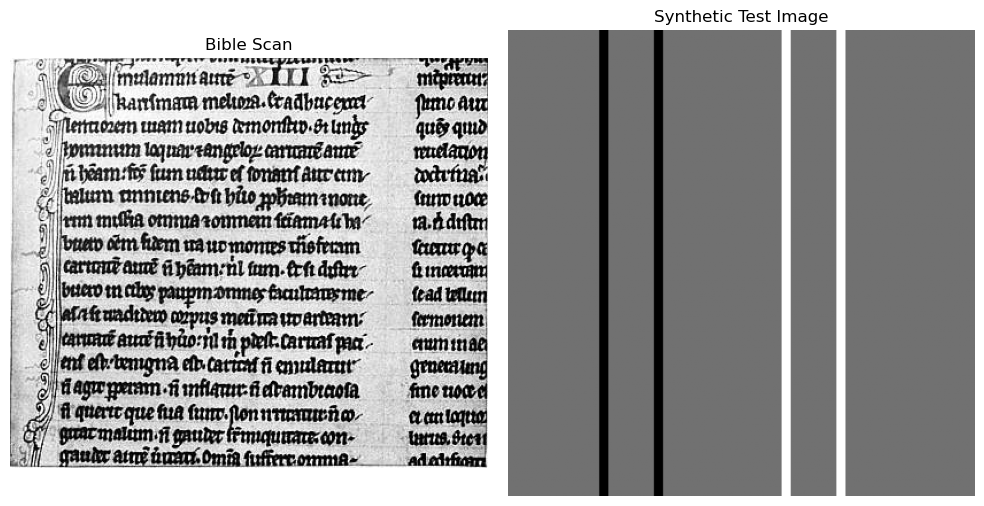

In [17]:
def create_test_image():
    img = np.ones((256, 256)) * 0.5
    img[:, 50:55] = 0.1
    img[:, 80:85] = 0.1
    img[:, 150:155] = 1.0
    img[:, 180:185] = 1.0
    
    return img

im = np.array(Image.open('extra_credit_3.png').convert('L'))
im = im.astype('float') / 255

im_test = create_test_image()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(im, cmap="gray")
axs[0].set_title("Bible Scan")
axs[0].axis("off")
axs[1].imshow(im_test, cmap="gray")
axs[1].set_title("Synthetic Test Image")
axs[1].axis("off")
plt.tight_layout()
plt.show()

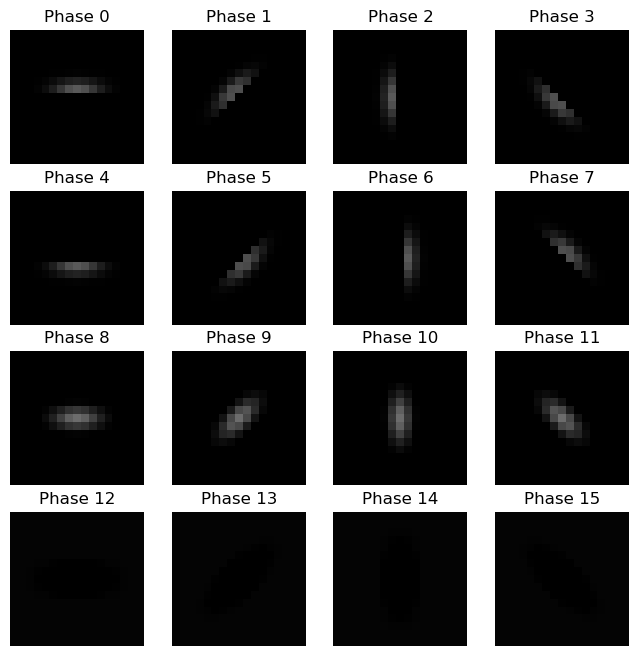

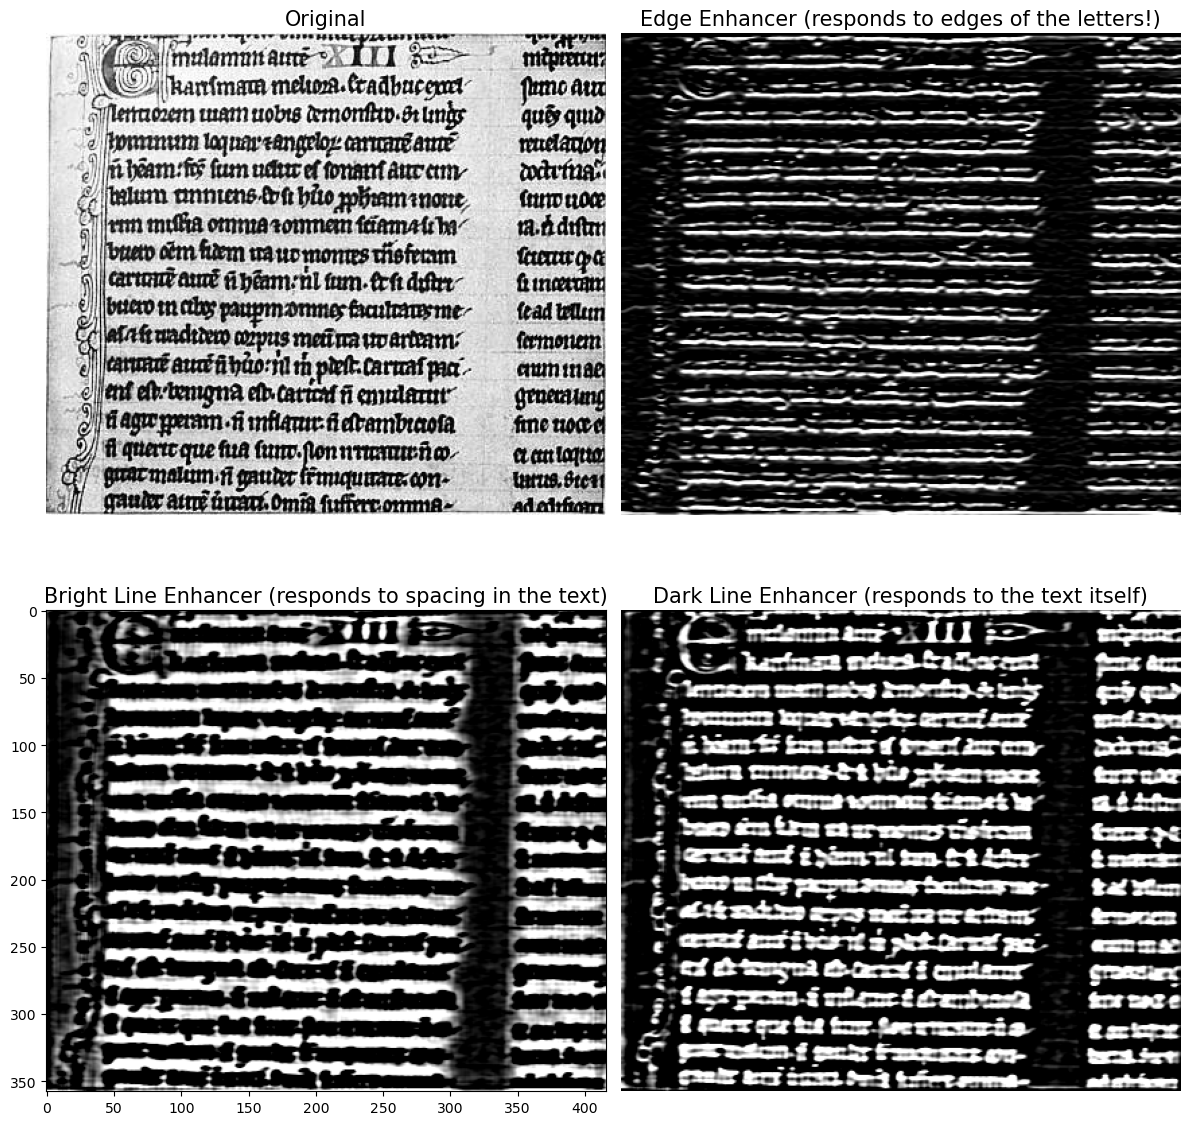

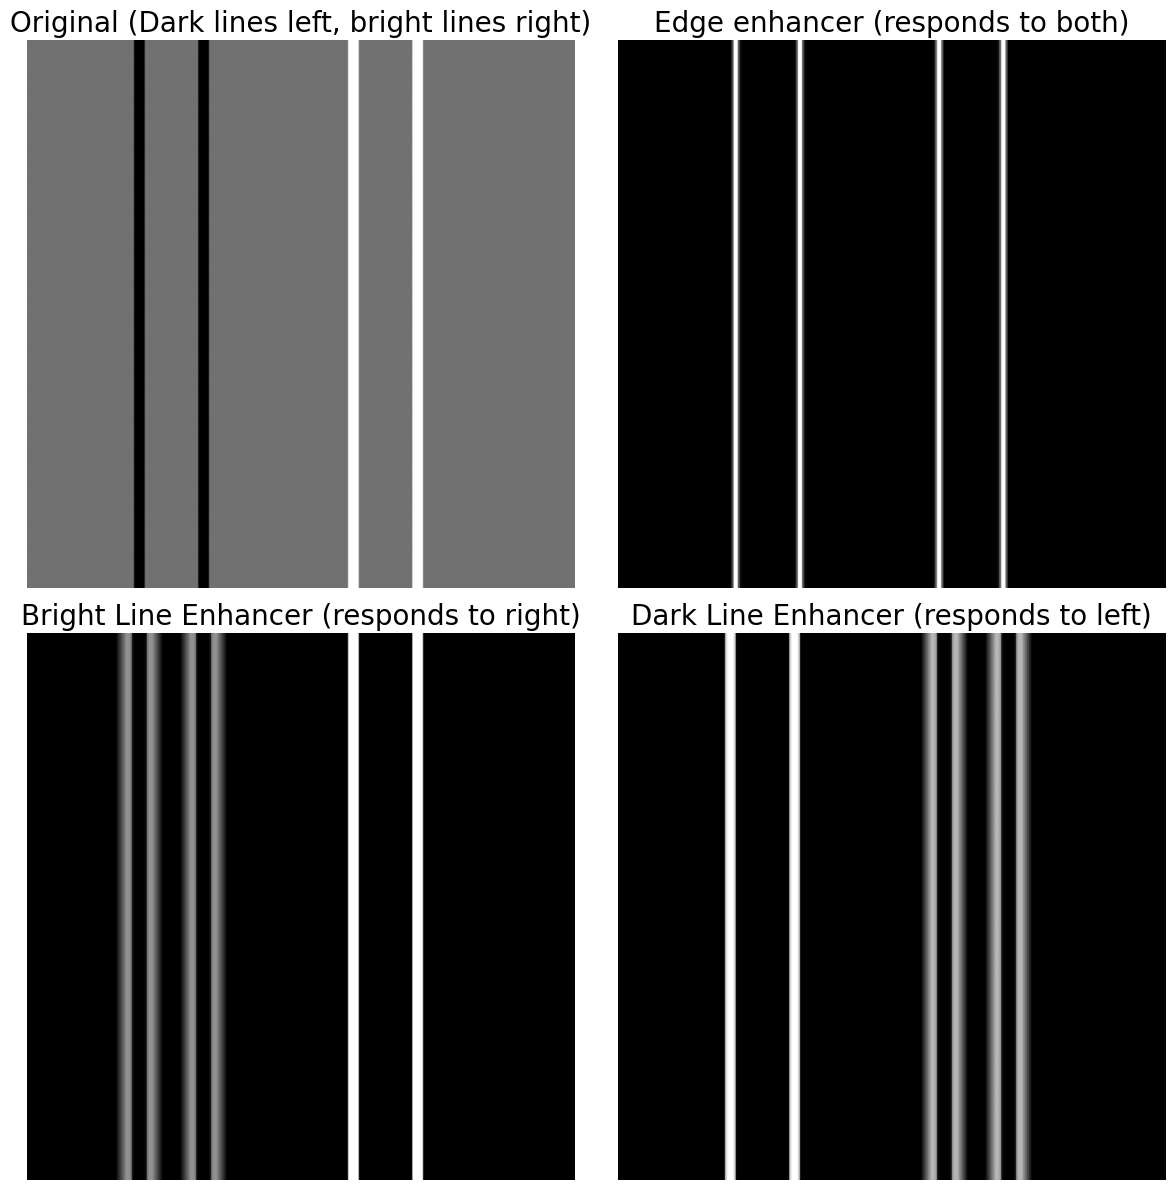

In [18]:
theta =0
wavelength = 12
phase=0
sigma=1
aspect=2
filters = gaborfilter(theta, wavelength, phase, sigma, aspect)
fig, ax = plt.subplots(4,4,figsize=(8,8))

for idx, (ax, filt) in enumerate(zip(ax.flatten(), filters)):
    ax.imshow(filt, cmap="gray", vmin=0,vmax=1)
    ax.set_title(f"Phase {idx}")
    ax.axis("off")

# text is horizontal, so use horizontal gabor filters
# filters[0] = edge enhancer (vertical, 0 degree rotation)
# filters[8] = bright line enhancer (vertical, 0 deg rot)
# filters[12] = dark line enhancer (vertical, 0 deg rot)

edge_response = convolve(im, filters[0])
bright_response = convolve(im, filters[8])
dark_response = convolve(im, filters[12])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(im, cmap="gray")
axes[0, 0].set_title("Original", fontsize=15)
axes[0, 0].axis("off")
axes[0, 1].imshow(edge_response, cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title("Edge Enhancer (responds to edges of the letters!)", fontsize=15)
axes[0, 1].axis("off")
axes[1, 0].imshow(bright_response, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Bright Line Enhancer (responds to spacing in the text)", fontsize=15)
axes[1, 1].axis("off")
axes[1, 1].imshow(dark_response, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("Dark Line Enhancer (responds to the text itself)", fontsize=15)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# vertical text, so we use vertical gabor filters
# filters[0] = edge enhancer (vertical, 0 degree rotation)
# filters[8] = bright line enhancer (vertical, 0 deg rot)
# filters[12] = dark line enhancer (vertical, 0 deg rot)

edge_response = convolve(im_test, filters[2])
bright_response = convolve(im_test, filters[10])
dark_response = convolve(im_test, filters[14])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(im_test, cmap="gray")
axes[0, 0].set_title("Original (Dark lines left, bright lines right)", fontsize=20)
axes[0, 0].axis("off")
axes[0, 1].imshow(edge_response, cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title("Edge enhancer (responds to both)", fontsize=20)
axes[0, 1].axis("off")
axes[1, 0].imshow(bright_response, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Bright Line Enhancer (responds to right)", fontsize=20)
axes[1, 0].axis("off")
axes[1, 1].imshow(dark_response, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("Dark Line Enhancer (responds to left)", fontsize=20)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# 3c

The primary visual cortex (v1) contains simple cells, whoose receptive fields relate directly to gabor filters! Neurons in the V1 respond to specific spatial frequencies and orientations, where for example, a specific neuron might fire rapidly only if it sees a horizonal bar of light with some width. Note that a gabor filer is a mathematical analogue of this process! Applying a bank of gabor filters is essentially simulating the visual cortex processing in the human brain! Having a single edge map causes a loss of information about the structure, as information is collapsed into a single scalar value representing edge intensity per pixel. This is useful, because it lets us know that an edge exists and how strongly so, BUT it discards all information about which way that edge is pointing. Therefore, by separating out into oriented maps as in gabor filters, we get a richer representation of the data that keeps edges in tact while also providing additional information about directional strength. Id imagine that gabor filters are advantageous for suppressing random noise, much moreso than the earlier single edge map, because the gabor filters will only respond strongly if the underlying signal looks like a gabor filter. In contrast, the single edge map is performs poorly because the derivatives amplify all high frequency noise. Additionally, as we discussed in class, certain situations require understanding of a distribution of orientations in the real world. For example, a mouse needs to understand how a field of grass is oriented in order to understand that it can run through the brush versus a wall for example. A single edge map cannot easily distinguish these but an orientation match (gabor filter match) can perfectly do so immediatelly. 

# 3d

In the space domain a gabor filter is the product of a gaussian and a sinusoid. note that multiplication in the space domain equals convolution in the frequency domain (by convolution theorum). The fourier transform of the gaussian component of the gabor filter is just another gaussian in teh frequency domain, except its width is inversely proportional to the spatial width (i.e. a wide gaussian becomes a narrow spectral gaussian). The fourier transform of the sinusoid component of the gabor filter will be a pair of dirac delta functions. Convolving the frequency domain gaussain w/ the pair of deltas simply duplicates the gaussian and shifts it to the locations of the two deltas! This is precisely the behavior we observe in the plots, with the frequency domain 2d/3d representations being two gaussians placed at the locations of the deltas!

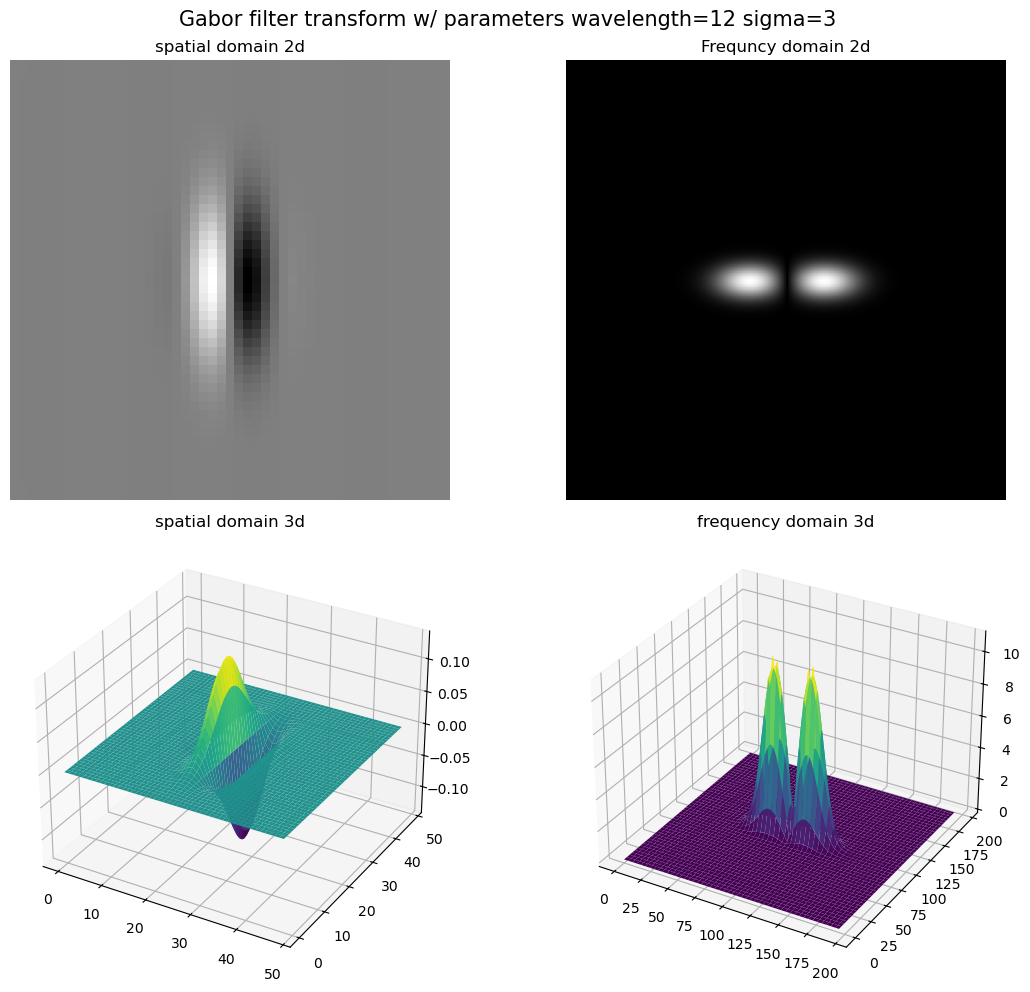

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift

sigma = 3
aspect = 2
wavelength = 12
# theta and phase handled by my imiplementation of gabor so we just pass dummy values
# generate full bank of filters
filters = gaborfilter(0, wavelength, 0, sigma, aspect)

# select 3rd filter (vertical edge, pi/2) to analyze
selected_gabor = filters[2]
spatial_gabor = filters[2]

height, width = spatial_gabor.shape
x = np.arange(width)
y = np.arange(height)
X_spatial_axis_val, Y_spatial_axis_val = np.meshgrid(x, y)
Z_spatial_axis_val = spatial_gabor

pad_h = height * 4
padd_w = width * 4

gabor_freqquency = fft2(spatial_gabor, s=(pad_h, padd_w))
gabor_frequency_shifted = fftshift(gabor_freqquency)
Z_freq = np.abs(gabor_frequency_shifted)

range_w = np.arange(padd_w)
range_h = np.arange(pad_h)
X_freq, Y_freq = np.meshgrid(range_w, range_h)

# compute forier transform, pad it aswell so it looks nice visually
pad_rows = selected_gabor.shape[0] * 8
pad_cols = selected_gabor.shape[1] * 8
gabor_freq = fft2(selected_gabor, s=(pad_rows, pad_cols))
gabor_frequency_shifted = fftshift(gabor_freq)

fig = plt.figure(figsize=(12, 10))

# 2d spatial
ax1 = fig.add_subplot(2, 2, 1) 
im1 = ax1.imshow(selected_gabor, cmap="gray")
ax1.set_title("spatial domain 2d")
ax1.axis("off")

# 2d frequency
ax2 = fig.add_subplot(2, 2, 2) 
im2 = ax2.imshow(Z_freq, cmap="gray")
ax2.set_title("Frequncy domain 2d")
ax2.axis("off")

# 3d spatial
ax3 = fig.add_subplot(2, 2, 3, projection="3d")
surf1 = ax3.plot_surface(X_spatial_axis_val, Y_spatial_axis_val, Z_spatial_axis_val, 
                         cmap="viridis",
                         edgecolor="none", linewidth=0, antialiased=True)
ax3.set_title("spatial domain 3d")

# 3d frequency
ax4 = fig.add_subplot(2, 2, 4, projection="3d")
surf2 = ax4.plot_surface(X_freq, Y_freq, Z_freq, cmap="viridis",
                         edgecolor="none", linewidth=0, antialiased=True)
ax4.set_title("frequency domain 3d")

plt.suptitle(f"Gabor filter transform w/ parameters wavelength={wavelength} sigma={sigma}", fontsize=15)
plt.tight_layout()
plt.show()